In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/iammustafatz/diabetes-prediction-dataset/diabetes_prediction_dataset.csv
/kaggle/input/datasets/lovishbansal123/titanic-dataset/Titanic-Dataset.csv
/kaggle/input/datasets/zerotrace11/tech-company-dataset/tech_company_employee_data_1000.csv
/kaggle/input/datasets/shree1992/housedata/output.csv
/kaggle/input/datasets/shree1992/housedata/data.csv
/kaggle/input/datasets/shree1992/housedata/data.dat
/kaggle/input/datasets/sagnikpatra/uci-adult-census-data-dataset/adult_train.csv
/kaggle/input/datasets/sagnikpatra/uci-adult-census-data-dataset/adult_test.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# impute missing values of occupation column of uci dataset

In [3]:
uci = pd.read_csv('/kaggle/input/datasets/sagnikpatra/uci-adult-census-data-dataset/adult_train.csv')
diabetes = pd.read_csv('/kaggle/input/datasets/iammustafatz/diabetes-prediction-dataset/diabetes_prediction_dataset.csv')
titanic = pd.read_csv('/kaggle/input/datasets/lovishbansal123/titanic-dataset/Titanic-Dataset.csv')
house = pd.read_csv('/kaggle/input/datasets/shree1992/housedata/data.csv')

In [4]:
uci

,Age,Workclass,fnlwgt,Education,Education_Num,Martial_Status,Occupation,Relationship,Race,Sex,Capital_Gain,Capital_Loss,Hours_per_week,Country,Target
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [5]:
uci["Occupation"].isnull().sum().sum()

np.int64(1843)

In [6]:

from sklearn.impute import SimpleImputer

uci["Occupation"] = uci["Occupation"].replace("?", np.nan)

imputer = SimpleImputer(strategy="most_frequent")
uci[["Occupation"]] = imputer.fit_transform(uci[["Occupation"]])

In [7]:
uci["Occupation"].isnull().sum()

np.int64(0)

# Outliers

# 1. find and mitigate(trimming and capping both) outliers on age column of diabetes dataset

In [8]:
diabetes

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


In [9]:
diabetes['age']

0        80.0
1        54.0
2        28.0
3        36.0
4        76.0
         ... 
99995    80.0
99996     2.0
99997    66.0
99998    24.0
99999    57.0
Name: age, Length: 100000, dtype: float64

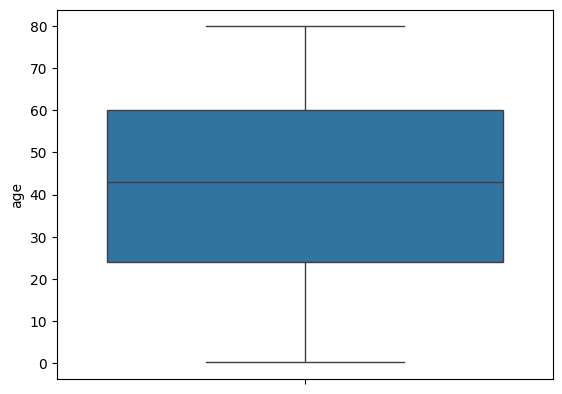

In [10]:
sns.boxplot(diabetes['age'])
plt.show()

In [11]:
p25= diabetes['age'].quantile(0.25)
p25

np.float64(24.0)

In [12]:

p75= diabetes['age'].quantile(0.75)
p75

np.float64(60.0)

In [13]:
iqr = p75 - p25
iqr

np.float64(36.0)

In [14]:
upper= p75 + 1.5 * iqr
lower= p25 - 1.5 * iqr

In [15]:
diabetes[diabetes["age"] > upper]

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes


In [16]:
diabetes[diabetes['age'] < lower]

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes


In [17]:
diabetes[(diabetes['age'] > upper) | (diabetes['age'] < lower)]

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes


In [19]:
new_ds= diabetes[(diabetes['bmi'] < upper) & (diabetes['bmi'] > lower)]
new_ds

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


In [20]:
new_ds_age = diabetes[(diabetes['age'] < upper) & (diabetes['age'] > lower)]
new_ds_age

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


In [21]:
new_ds_age.shape

(100000, 9)

In [24]:
new_df_cap = diabetes.copy()

new_df_cap['age'] = np.where(new_df_cap['age'] > upper, upper,
                             np.where(new_df_cap['age'] < lower, lower, new_df_cap['age']))

In [25]:
new_df_cap.shape

(100000, 9)

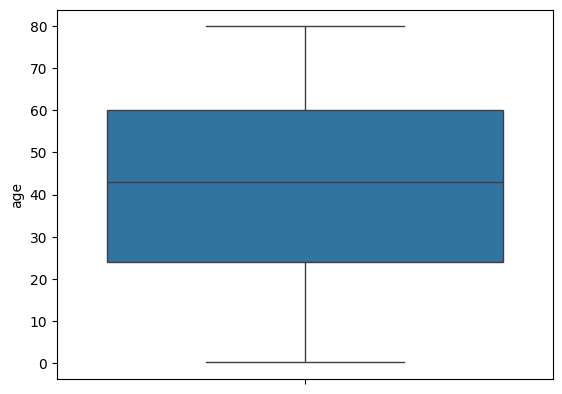

In [26]:
sns.boxplot(new_df_cap['age'])
plt.show()

# 2. find and mitigate(trimming and capping both) outliers on price column of house dataset

In [27]:
house

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,3.130000e+05,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2.384000e+06,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,3.420000e+05,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,4.200000e+05,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,5.500000e+05,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,2014-07-09 00:00:00,3.081667e+05,3.0,1.75,1510,6360,1.0,0,0,4,1510,0,1954,1979,501 N 143rd St,Seattle,WA 98133,USA
4596,2014-07-09 00:00:00,5.343333e+05,3.0,2.50,1460,7573,2.0,0,0,3,1460,0,1983,2009,14855 SE 10th Pl,Bellevue,WA 98007,USA
4597,2014-07-09 00:00:00,4.169042e+05,3.0,2.50,3010,7014,2.0,0,0,3,3010,0,2009,0,759 Ilwaco Pl NE,Renton,WA 98059,USA
4598,2014-07-10 00:00:00,2.034000e+05,4.0,2.00,2090,6630,1.0,0,0,3,1070,1020,1974,0,5148 S Creston St,Seattle,WA 98178,USA


In [28]:
house['price']

0       3.130000e+05
1       2.384000e+06
2       3.420000e+05
3       4.200000e+05
4       5.500000e+05
            ...     
4595    3.081667e+05
4596    5.343333e+05
4597    4.169042e+05
4598    2.034000e+05
4599    2.206000e+05
Name: price, Length: 4600, dtype: float64

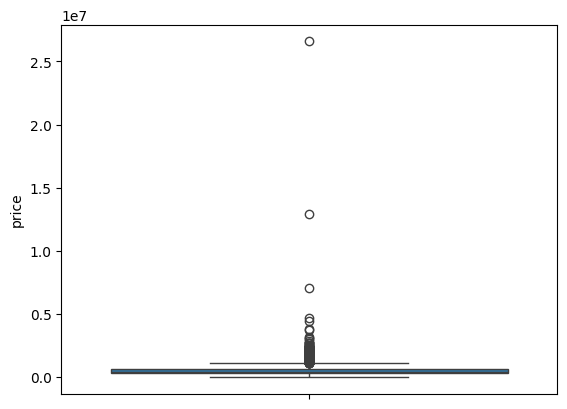

In [29]:
sns.boxplot(house['price'])
plt.show()

In [30]:
pr25= house['price'].quantile(0.25)
pr25

np.float64(322875.0)

In [31]:
pr75= house['price'].quantile(0.75)
pr75

np.float64(654962.5)

In [32]:
IQR = pr75 - pr25
IQR

np.float64(332087.5)

In [33]:
upper_limit= pr75 + 1.5 * IQR
lower_limit= pr25 - 1.5 * IQR

In [34]:
house[(house['price'] > upper_limit) | (house['price'] < lower_limit)]

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
1,2014-05-02 00:00:00,2.384000e+06,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
11,2014-05-02 00:00:00,1.400000e+06,4.0,2.50,2920,4000,1.5,0,0,5,1910,1010,1909,1988,3838-4098 44th Ave NE,Seattle,WA 98105,USA
14,2014-05-02 00:00:00,1.200000e+06,5.0,2.75,2910,9480,1.5,0,0,3,2910,0,1939,1969,3534 46th Ave NE,Seattle,WA 98105,USA
99,2014-05-05 00:00:00,1.395000e+06,5.0,3.50,4010,8510,2.0,0,1,5,2850,1160,1971,0,3930 NE Belvoir Pl,Seattle,WA 98105,USA
122,2014-05-05 00:00:00,2.280000e+06,7.0,8.00,13540,307752,3.0,0,4,3,9410,4130,1999,0,26408 NE 70th St,Redmond,WA 98053,USA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4348,2014-05-05 00:00:00,2.199900e+06,4.0,1.50,1120,5427,1.0,0,0,3,1120,0,1969,2014,19009-19021 SE 266th St,Covington,WA 98042,USA
4350,2014-07-03 00:00:00,2.659000e+07,3.0,2.00,1180,7793,1.0,0,0,4,1180,0,1992,0,12005 SE 219th Ct,Kent,WA 98031,USA
4465,2014-06-05 00:00:00,2.560498e+06,3.0,2.50,1710,1664,2.0,0,0,5,1300,410,2003,0,2826 21st Ave W,Seattle,WA 98199,USA
4467,2014-06-06 00:00:00,1.337044e+06,4.0,3.50,4280,9583,2.0,0,0,3,4280,0,2005,0,1415 108th Ave SE,Bellevue,WA 98004,USA


In [36]:
house.shape

(4600, 18)

In [38]:
house1 = house[(house['price'] < upper_limit) & (house['price'] > lower_limit)]
house1

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.000000,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
2,2014-05-02 00:00:00,342000.000000,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.000000,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.000000,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA
5,2014-05-02 00:00:00,490000.000000,2.0,1.00,880,6380,1.0,0,0,3,880,0,1938,1994,522 NE 88th St,Seattle,WA 98115,USA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,2014-07-09 00:00:00,308166.666667,3.0,1.75,1510,6360,1.0,0,0,4,1510,0,1954,1979,501 N 143rd St,Seattle,WA 98133,USA
4596,2014-07-09 00:00:00,534333.333333,3.0,2.50,1460,7573,2.0,0,0,3,1460,0,1983,2009,14855 SE 10th Pl,Bellevue,WA 98007,USA
4597,2014-07-09 00:00:00,416904.166667,3.0,2.50,3010,7014,2.0,0,0,3,3010,0,2009,0,759 Ilwaco Pl NE,Renton,WA 98059,USA
4598,2014-07-10 00:00:00,203400.000000,4.0,2.00,2090,6630,1.0,0,0,3,1070,1020,1974,0,5148 S Creston St,Seattle,WA 98178,USA


In [41]:
house1.shape

(4360, 18)

In [51]:
house1_cap = house.copy()

house1_cap['price'] = np.where(house1_cap['price'] > upper_limit, upper_limit,
                                  np.where(house1_cap['price'] < lower_limit, lower_limit, house1_cap['price']))

In [52]:
house1_cap.shape

(4600, 18)

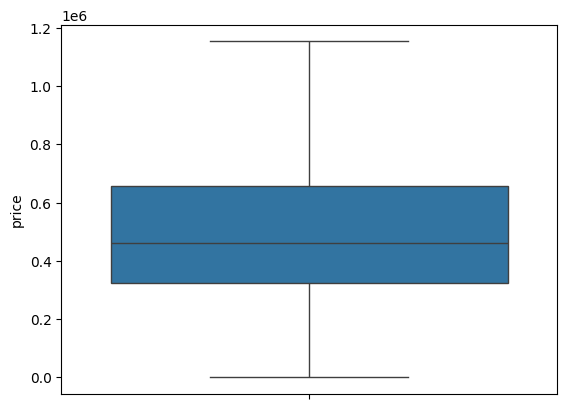

In [54]:
sns.boxplot(house1_cap['price'])
plt.show()